In [4]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from adjustText import adjust_text

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)



/var/folders/rs/2j_2x6c957d4bvk4bj1xdkzh0000gn/T/ipykernel_39784/2973896677.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, tick_labels = job_titles, vert = False)


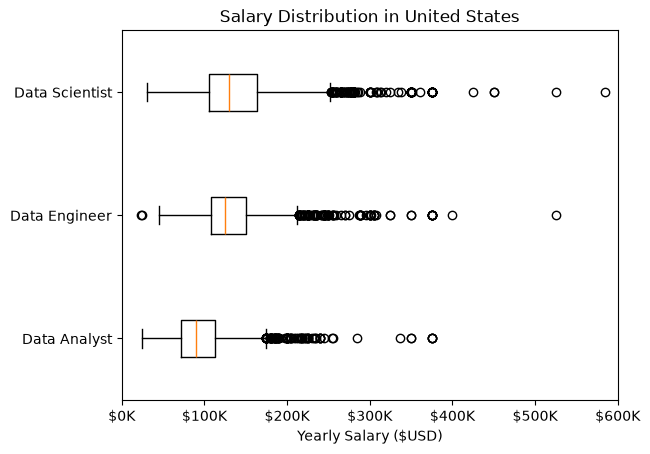

In [9]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
Needed = df[(df['job_country'] == 'United States') & df['job_title_short'].isin(job_titles)].copy()
Needed = Needed.dropna(subset=['salary_year_avg'])

job_list = [Needed[Needed['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, tick_labels = job_titles, vert = False)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _ : f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.title('Salary Distribution in United States')
plt.xlabel('Yearly Salary ($USD)')
plt.show()